<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20CT002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gradient Strength | Memory Fidelity
------------------|-----------------
             0.00 |  0.9494
             0.11 |  0.9604
             0.22 |  0.9821
             0.33 |  0.9898
             0.44 |  0.9941
             0.56 |  0.9948
             0.67 |  0.9968
             0.78 |  0.9968
             0.89 |  0.9979
             1.00 |  0.9969


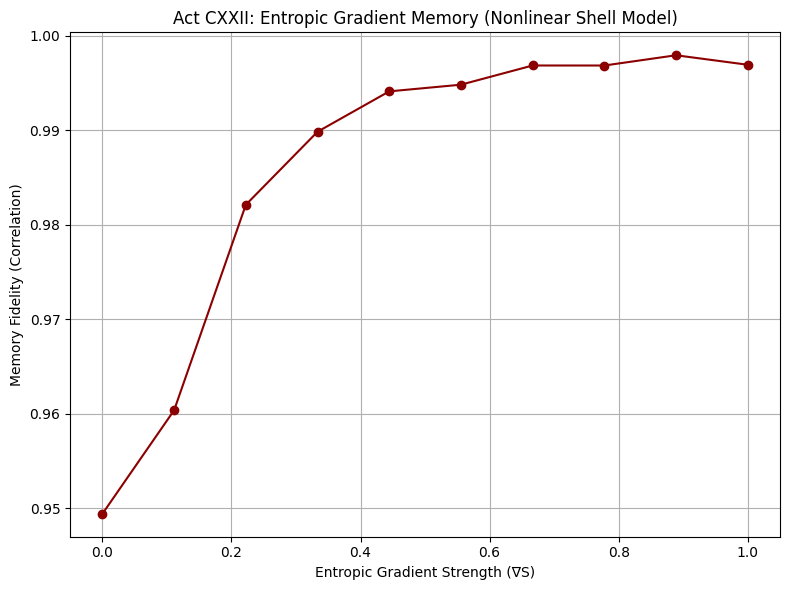

In [ ]:
# Act CXXII: Entropic Gradient Memory — Nonlinear Shell Model
# Copy, paste, run = results

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
np.random.seed(42)              # reproducibility
N = 1000                        # lattice size (1D for simplicity)
timesteps = 200                 # simulation steps
alpha = 0.05                    # coupling constant for nonlinear term
gradient_levels = np.linspace(0.0, 1.0, 10)  # entropic gradient sweep

# --- Functions ---
def initialize_entropy_shells(N, gradient_strength, num_shells=5):
    """
    Concentric shell-based entropy layering.
    Each shell level increases with gradient_strength.
    """
    shell_size = N // num_shells
    entropy = np.zeros(N)
    for i in range(num_shells):
        base_entropy = gradient_strength * (i / (num_shells - 1))
        start = i * shell_size
        end = (i + 1) * shell_size if i < num_shells - 1 else N
        # small intra-shell noise
        entropy[start:end] = base_entropy + 0.05 * np.random.randn(end - start)
    return entropy

def memory_fidelity(initial_state, evolved_state):
    """Pearson correlation between initial and evolved state."""
    return np.corrcoef(initial_state, evolved_state)[0, 1]

def evolve_entropy_nonlinear(state, alpha, timesteps):
    """
    Nonlinear entropic gradient coupling:
      dS/dt = - alpha * (∇S)^2
    Discrete update: S <- S - alpha * (grad^2)
    """
    evolved = state.copy()
    for _ in range(timesteps):
        grad = np.gradient(evolved)
        evolved -= alpha * (grad ** 2)
    return evolved

# --- Simulation Sweep ---
results = []
print("Gradient Strength | Memory Fidelity")
print("------------------|-----------------")
for g in gradient_levels:
    initial = initialize_entropy_shells(N, g)
    evolved = evolve_entropy_nonlinear(initial, alpha, timesteps)
    fidelity = memory_fidelity(initial, evolved)
    results.append((g, fidelity))
    print(f"{g:17.2f} | {fidelity: .4f}")

# --- Results Plot ---
gradients, fidelities = zip(*results)

plt.figure(figsize=(8, 6))
plt.plot(gradients, fidelities, marker='o', color='darkred')
plt.title("Act CXXII: Entropic Gradient Memory (Nonlinear Shell Model)")
plt.xlabel("Entropic Gradient Strength (∇S)")
plt.ylabel("Memory Fidelity (Correlation)")
plt.grid(True)
plt.tight_layout()
plt.show()
